<a href="https://colab.research.google.com/github/Carolmeloc/CaracteristicasRadiomicas/blob/main/CaracteristicasRadiomicas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Paradigmas de Aprendizagem de Máquina - Prova 02: Análise de Características Radiômicas.

## Configuração Inicial

### Importando bibliotecas

Logo no início, importei as principais bibliotecas que ia precisar:

* pandas e numpy pra manipulação de dados;

* matplotlib.pyplot e seaborn pra visualizações;

* Algumas do sklearn, que são essenciais pra modelagem, pré-processamento e avaliação dos modelos.

Também carreguei o warnings com um filtro pra esconder mensagens que poderiam poluir a saída, deixando o notebook mais limpo pra leitura.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')

Fixei a semente aleatória (random_state = 42) tanto no numpy quanto nos métodos que permitem esse controle. Isso é importante porque muitos algoritmos (tipo K-means, train/test split, etc.) fazem escolhas aleatórias — e fixar a semente garante que os resultados sejam os mesmos toda vez que o código rodar, o que é essencial em trabalhos científicos.

In [ ]:
# Para reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### Carregando base de dados

Como o notebook foi feito no Google Colab, usei o método files.upload() pra permitir que o usuário envie o CSV manualmente. Assim que o arquivo radiomic_data_binary.csv é carregado, ele é lido com pd.read_csv().

In [ ]:
from google.colab import files
uploaded = files.upload()  # Upload do arquivo radiomic_data_binary.csv

Saving radiomic_data_binary.csv to radiomic_data_binary (2).csv


Logo em seguida, fiz algumas análises iniciais:

* Mostrei o tamanho do dataset com df.shape;

* Usei df.info() pra ver o tipo de dados de cada coluna e se havia valores nulos;

* Visualizei a distribuição das classes com um gráfico de barras.

Essa etapa é tipo um "check-up" inicial dos dados, pra entender com o que a gente tá lidando — se as classes estão balanceadas, se há problemas de preenchimento, e se as variáveis já estão no formato correto.

Antes de mexer no modelo, plotei alguns histogramas das primeiras features só pra ter uma noção da distribuição. Isso ajuda a identificar se existem outliers, se os dados são simétricos, etc. — e até influencia nas escolhas de normalização e nos modelos que serão aplicados depois.

Dimensões do dataset: (2018, 116)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Columns: 116 entries, diagnostics_Versions_PyRadiomics to class
dtypes: float64(96), int64(2), object(18)
memory usage: 1.8+ MB


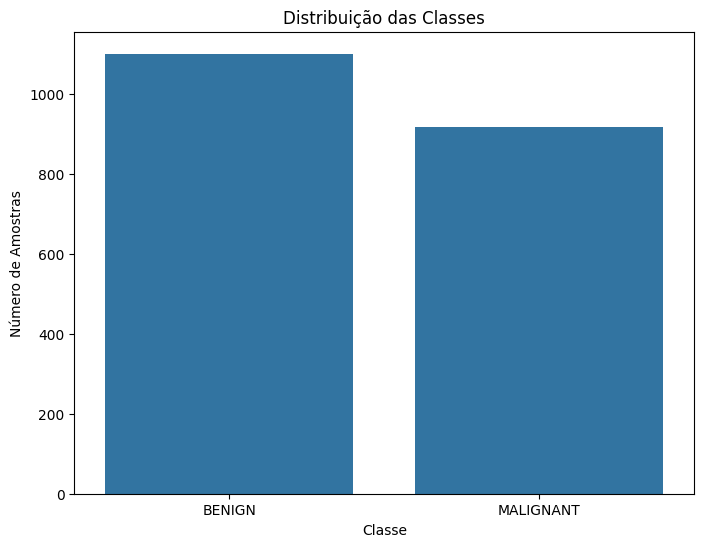

class
BENIGN       1100
MALIGNANT     918
Name: count, dtype: int64

Colunas com valores ausentes:
Series([], dtype: int64)


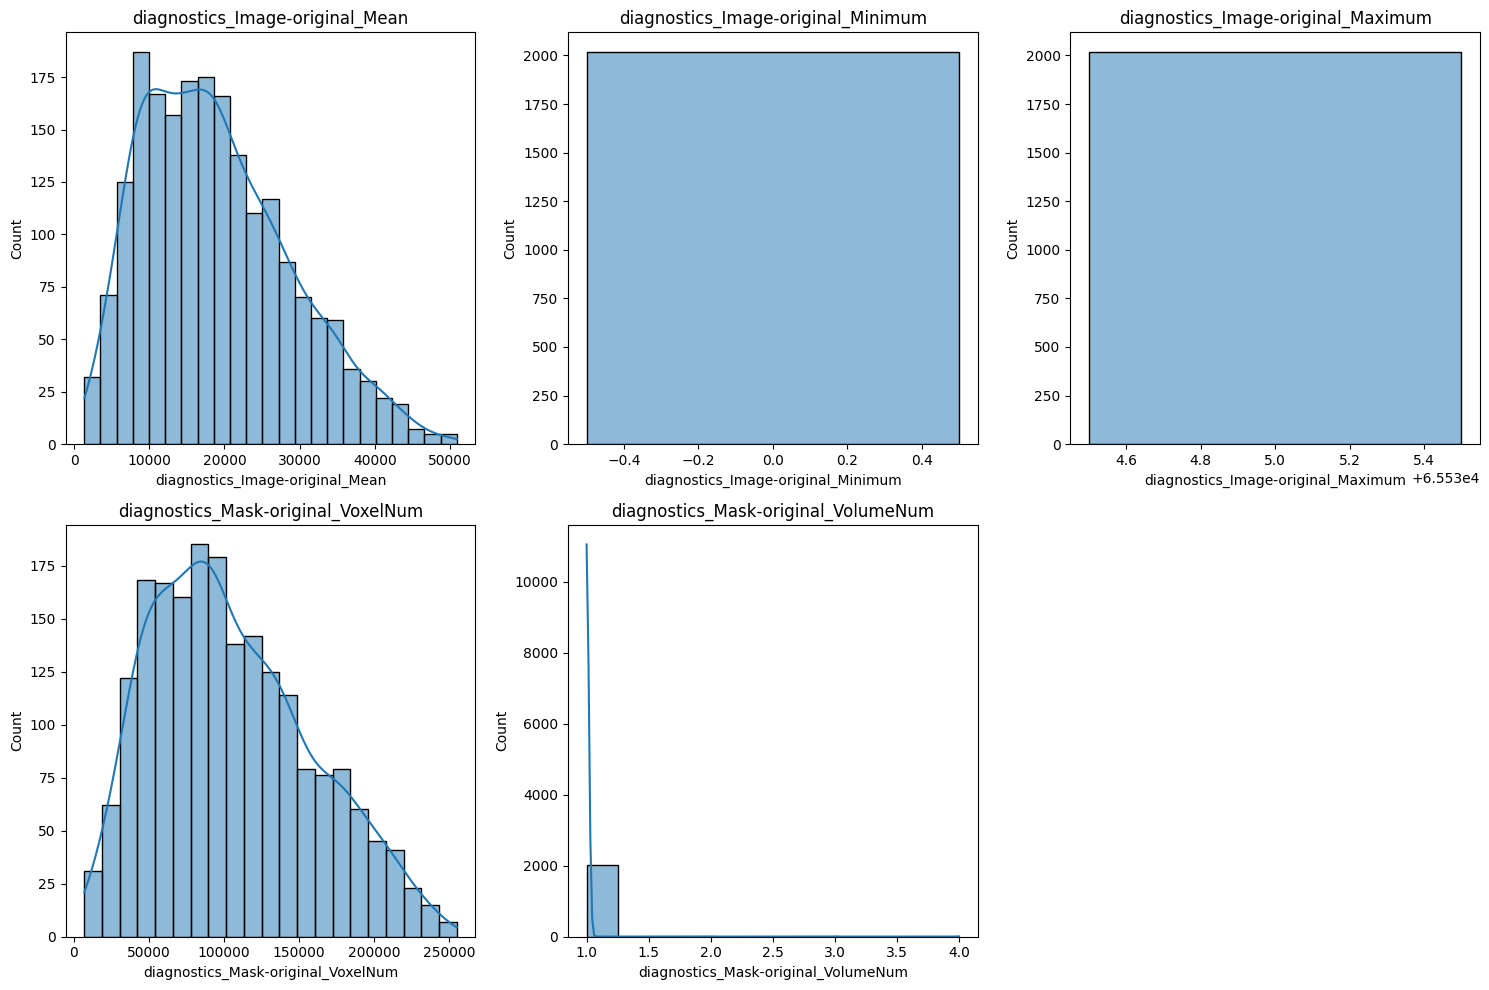

In [ ]:
# Carregando os dados
df = pd.read_csv(list(uploaded.keys())[0])

print(f"Dimensões do dataset: {df.shape}")
df.head()

# Verificando as informações básicas do dataset
df.info()

# Verificando a distribuição das classes
plt.figure(figsize=(8, 6))
class_counts = df['class'].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Distribuição das Classes')
plt.ylabel('Número de Amostras')
plt.xlabel('Classe')
plt.show()

print(df['class'].value_counts())

# Análise de valores ausentes
missing_values = df.isnull().sum()
print("\nColunas com valores ausentes:")
print(missing_values[missing_values > 0])

# Verificando a distribuição de algumas features
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.select_dtypes(include=['float64', 'int64']).columns[:5]):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

Essa parte inicial é meio "invisível" na hora da entrega, mas é super importante porque:

* Prepara o ambiente de forma organizada e controlada;

* Garante que todo o resto do trabalho seja reprodutível e transparente;

* Dá uma primeira visão do que esperar dos dados — inclusive se vai ser necessário algum tratamento especial.

# Questão 01 - Classificação Supervisionada

Nessa primeira parte, a ideia foi usar os dados radiômicos extraídos das mamografias pra tentar classificar se uma lesão era benigna ou maligna. Como são muitas features (mais de 100), comecei com um pré-processamento básico, que inclui:

* Verificação e tratamento de valores ausentes (não tinha muita coisa faltando, mas preenchi com a média pra não perder informação);

* Padronização com StandardScaler, porque os valores das features variam bastante e isso pode atrapalhar os modelos, especialmente PCA e redes neurais;

* Também converti os rótulos de texto ("BENIGN", "MALIGNANT") para números, porque os modelos precisam disso pra funcionar.



### A) Pré-processamento da base de dados

In [ ]:
# Separando features e target
X = df.drop('class', axis=1)
y = df['class']

# Convertendo a variável target para numérica
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)
print(f"Classes codificadas: {le.classes_} -> {np.unique(y)}")

# Verificando se há colunas não numéricas
non_numeric_cols = X.select_dtypes(exclude=np.number).columns
if len(non_numeric_cols) > 0:
    print(f"Colunas não numéricas encontradas: {non_numeric_cols}")
    # Removendo colunas não numéricas se houver
    X = X.select_dtypes(include=np.number)
    print(f"Usando apenas colunas numéricas: {X.shape[1]} features")

Classes codificadas: ['BENIGN' 'MALIGNANT'] -> [0 1]
Colunas não numéricas encontradas: Index(['diagnostics_Versions_PyRadiomics', 'diagnostics_Versions_Numpy',
       'diagnostics_Versions_SimpleITK', 'diagnostics_Versions_PyWavelet',
       'diagnostics_Versions_Python', 'diagnostics_Configuration_Settings',
       'diagnostics_Configuration_EnabledImageTypes',
       'diagnostics_Image-original_Hash',
       'diagnostics_Image-original_Dimensionality',
       'diagnostics_Image-original_Spacing', 'diagnostics_Image-original_Size',
       'diagnostics_Mask-original_Hash', 'diagnostics_Mask-original_Spacing',
       'diagnostics_Mask-original_Size',
       'diagnostics_Mask-original_BoundingBox',
       'diagnostics_Mask-original_CenterOfMassIndex',
       'diagnostics_Mask-original_CenterOfMass'],
      dtype='object')
Usando apenas colunas numéricas: 98 features


In [ ]:
# Tratamento de valores ausentes
from sklearn.impute import SimpleImputer

# Verificando valores ausentes
missing_values = X.isnull().sum()
if missing_values.sum() > 0:
    print(f"Total de valores ausentes: {missing_values.sum()}")
    print("Colunas com valores ausentes:")
    print(missing_values[missing_values > 0])

In [ ]:
# Aplicando o imputer
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

In [ ]:
# Normalização dos dados
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [ ]:
# Convertendo de volta para DataFrame para facilitar a visualização
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

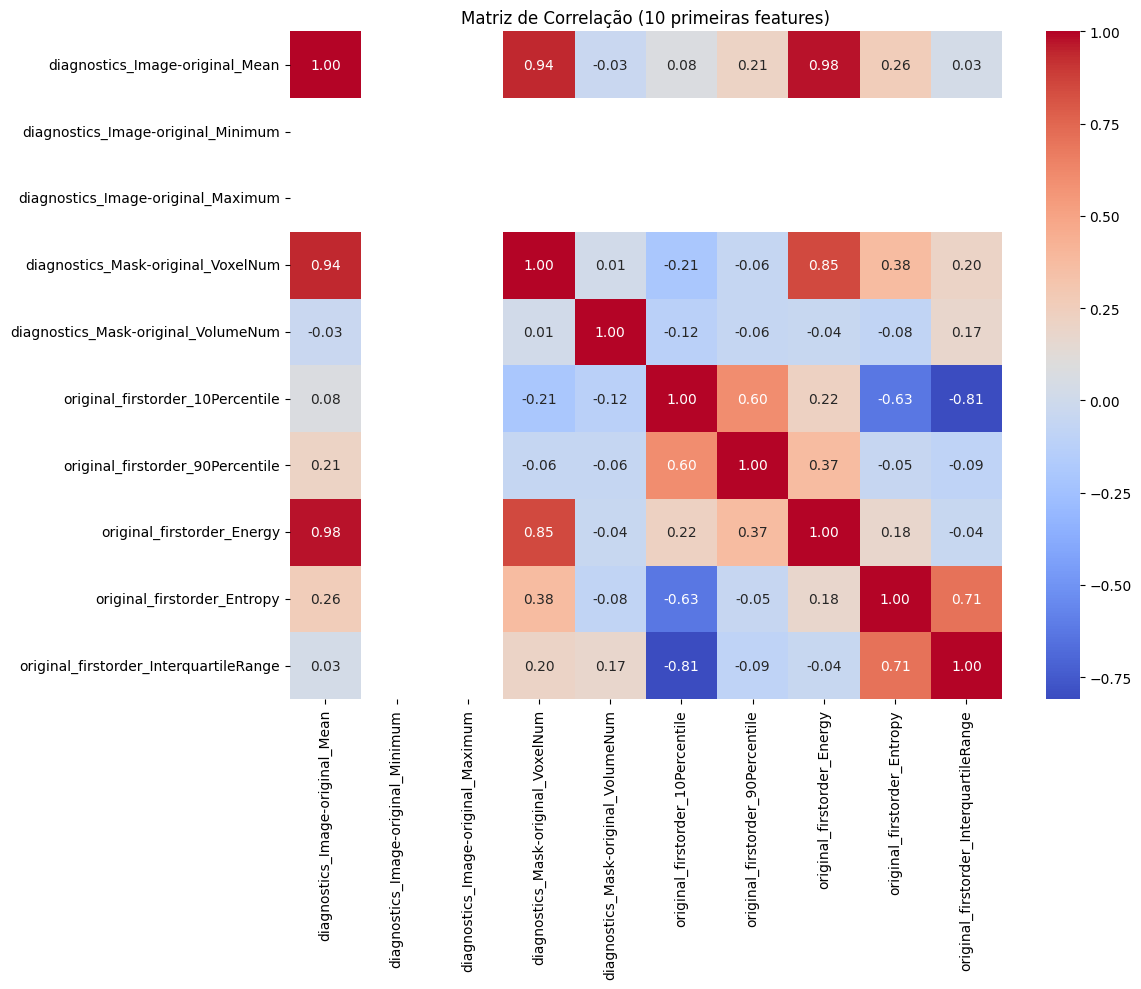

In [ ]:
# Verificando correlação entre features para entender melhor os dados
plt.figure(figsize=(12, 10))
correlation_matrix = X_scaled_df.iloc[:, :10].corr()  # Primeiras 10 features para melhor visualização
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação (10 primeiras features)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Abordagem 1: Seleção de features usando SelectKBest com f_classif
k_best = 20  # Número de features a serem selecionadas
selector_f = SelectKBest(f_classif, k=k_best)
X_kbest_f = selector_f.fit_transform(X_scaled, y)

# Features selecionadas com f_classif
selected_features_f = X.columns[selector_f.get_support()]
print(f"Features selecionadas (f_classif): {selected_features_f}")

Features selecionadas (f_classif): Index(['original_firstorder_90Percentile', 'original_firstorder_Entropy',
       'original_firstorder_Mean', 'original_firstorder_Median',
       'original_firstorder_RootMeanSquared', 'original_glcm_Contrast',
       'original_glcm_DifferenceAverage', 'original_glcm_DifferenceVariance',
       'original_glcm_Imc1', 'original_glcm_Imc2',
       'original_glcm_InverseVariance', 'original_glcm_JointEntropy',
       'original_gldm_DependenceEntropy',
       'original_glrlm_GrayLevelNonUniformityNormalized',
       'original_glrlm_RunEntropy',
       'original_glszm_GrayLevelNonUniformityNormalized',
       'original_glszm_ZoneEntropy', 'original_ngtdm_Busyness',
       'original_ngtdm_Coarseness', 'original_ngtdm_Contrast'],
      dtype='object')


In [ ]:
# Abordagem 2: Seleção de features usando SelectKBest com mutual_info_classif
selector_mi = SelectKBest(mutual_info_classif, k=k_best)
X_kbest_mi = selector_mi.fit_transform(X_scaled, y)

# Features selecionadas com mutual_info_classif
selected_features_mi = X.columns[selector_mi.get_support()]
print(f"Features selecionadas (mutual_info_classif): {selected_features_mi}")

Features selecionadas (mutual_info_classif): Index(['diagnostics_Mask-original_VoxelNum', 'original_firstorder_Entropy',
       'original_firstorder_MeanAbsoluteDeviation', 'original_firstorder_Mean',
       'original_firstorder_RobustMeanAbsoluteDeviation',
       'original_glcm_Autocorrelation', 'original_glcm_Correlation',
       'original_glcm_Imc1', 'original_gldm_DependenceNonUniformity',
       'original_gldm_DependenceNonUniformityNormalized',
       'original_gldm_LargeDependenceEmphasis',
       'original_gldm_SmallDependenceEmphasis',
       'original_glrlm_GrayLevelNonUniformity',
       'original_glrlm_LongRunLowGrayLevelEmphasis',
       'original_glrlm_RunEntropy', 'original_glrlm_RunLengthNonUniformity',
       'original_glrlm_RunVariance',
       'original_glszm_GrayLevelNonUniformityNormalized',
       'original_glszm_ZonePercentage', 'original_ngtdm_Coarseness'],
      dtype='object')


In [ ]:
# Abordagem 3: Redução de dimensionalidade via PCA
pca = PCA(n_components=k_best)
X_pca = pca.fit_transform(X_scaled)

Achei importante reduzir a dimensionalidade. Trabalhar com 116 features pode deixar os modelos mais lentos, confusos ou até overfitting. Então testei três métodos:

* SelectKBest com teste F (f_classif) — que avalia quais atributos estão mais relacionados com a variável-alvo;

* SelectKBest com mutual information, que vê a dependência não linear entre as variáveis;

* PCA — que não usa os rótulos, mas transforma os dados em componentes que explicam a maior parte da variância.

Com o PCA, analisei quanta variância era explicada por cada componente e percebi que com cerca de 20 a 25 componentes dava pra manter 95% da informação. Isso guiou o corte que usei depois.

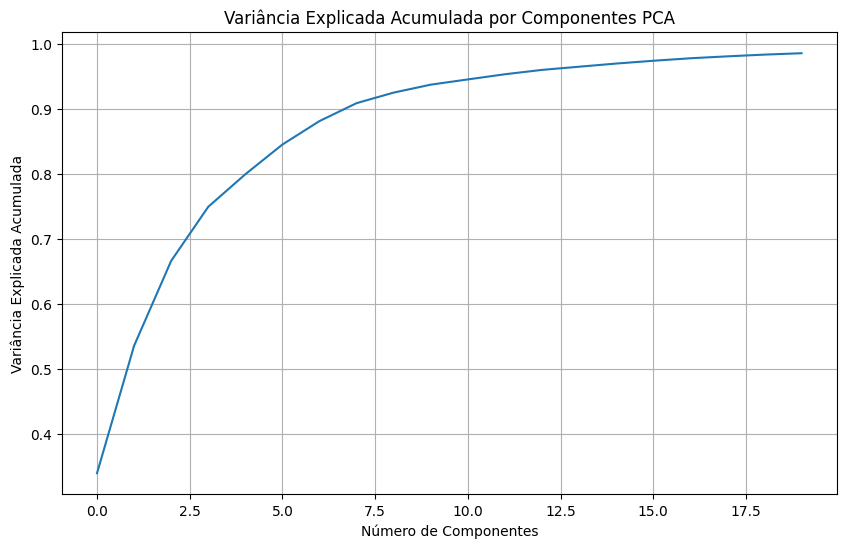

Variância explicada pelas 20 primeiras componentes: 0.9863


In [ ]:
# Variância explicada pelo PCA
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Variância Explicada Acumulada por Componentes PCA')
plt.grid(True)
plt.show()

print(f"Variância explicada pelas {k_best} primeiras componentes: {np.sum(pca.explained_variance_ratio_):.4f}")

In [ ]:
# Comparando o número de componentes necessárias para explicar 95% da variância
n_components_95 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
print(f"Número de componentes para explicar 95% da variância: {n_components_95}")

# Redefinindo PCA com o número de componentes que explicam 95% da variância
pca_95 = PCA(n_components=n_components_95)
X_pca_95 = pca_95.fit_transform(X_scaled)

# Preparando os conjuntos de dados para modelagem
datasets = {
    'Original (dados normalizados)': X_scaled,
    'SelectKBest (f_classif)': X_kbest_f,
    'SelectKBest (mutual_info)': X_kbest_mi,
    'PCA (k fixo)': X_pca,
    'PCA (95% var)': X_pca_95
}

Número de componentes para explicar 95% da variância: 12


### B) Treinamento e comparação de modelos

Aqui eu quis comparar alguns modelos diferentes, pra entender como eles se comportam com dados radiômicos. Usei:

* Árvore de Decisão;

* MLP (Perceptron Multicamadas);

* LightGBM (porque é rápido, funciona bem com muitos atributos e é muito usado em tarefas tabulares);

Além de outros, tipo Random Forest, SVC, KNN...

Avaliando tudo com acurácia, F1-score e matriz de confusão.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, confusion_matrix, roc_curve, auc, classification_report

# Configurando a validação cruzada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# Inicializando os modelos
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=RANDOM_STATE)

models = {
    'Decision Tree': dt,
    'MLP': mlp
}

In [ ]:
# Função para avaliar modelos
def evaluate_model(model, X, y, cv, dataset_name, model_name):
    # F1 Score
    f1_scores = cross_val_score(model, X, y, cv=cv, scoring='f1_weighted')
    mean_f1 = np.mean(f1_scores)
    std_f1 = np.std(f1_scores)

    print(f"Modelo: {model_name} | Dataset: {dataset_name}")
    print(f"F1 Score médio: {mean_f1:.4f} ± {std_f1:.4f}")

    # Predições para a matriz de confusão e curva ROC
    y_pred = cross_val_predict(model, X, y, cv=cv)

    # Matriz de Confusão
    cm = confusion_matrix(y, y_pred)

    # Relatório de classificação
    report = classification_report(y, y_pred, target_names=le.classes_)
    print("Relatório de Classificação:")
    print(report)

    # Predições de probabilidade para a curva ROC
    try:
        y_proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba')

        # Curva ROC
        fpr, tpr, _ = roc_curve(y, y_proba[:, 1])
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('Taxa de Falsos Positivos')
        plt.ylabel('Taxa de Verdadeiros Positivos')
        plt.title(f'Curva ROC - {model_name} - {dataset_name}')
        plt.legend(loc="lower right")
        plt.show()

        print(f"AUC-ROC: {roc_auc:.4f}\n")
    except:
        print("Este modelo não suporta predict_proba para gerar a curva ROC.\n")

    # Plotando a matriz de confusão
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.xlabel('Predição')
    plt.ylabel('Real')
    plt.title(f'Matriz de Confusão - {model_name} - {dataset_name}')
    plt.show()

    return mean_f1, roc_auc if 'roc_auc' in locals() else None


Avaliando dataset: Original (dados normalizados) (dimensões: (2018, 98))
Modelo: Decision Tree | Dataset: Original (dados normalizados)
F1 Score médio: 0.5673 ± 0.0276
Relatório de Classificação:
              precision    recall  f1-score   support

      BENIGN       0.61      0.59      0.60      1100
   MALIGNANT       0.52      0.54      0.53       918

    accuracy                           0.57      2018
   macro avg       0.56      0.56      0.56      2018
weighted avg       0.57      0.57      0.57      2018



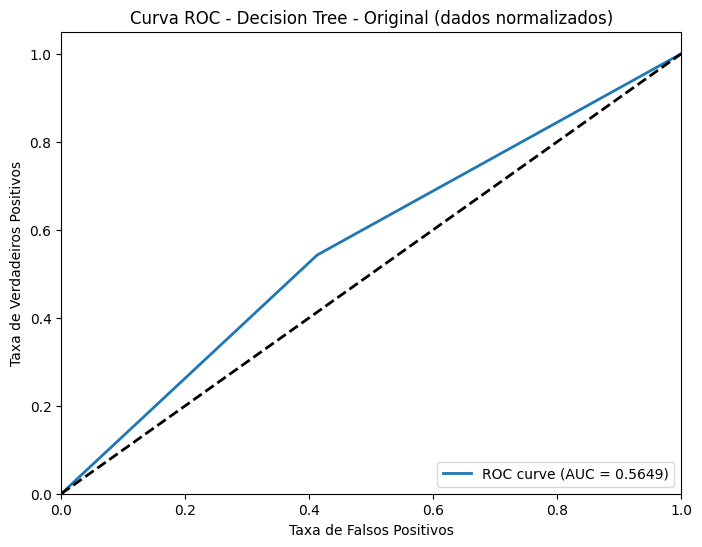

AUC-ROC: 0.5649



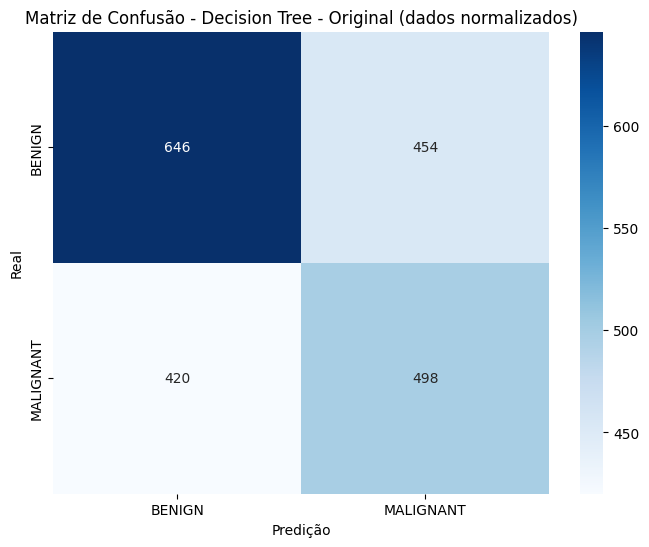

Modelo: MLP | Dataset: Original (dados normalizados)
F1 Score médio: 0.6313 ± 0.0392
Relatório de Classificação:
              precision    recall  f1-score   support

      BENIGN       0.65      0.71      0.68      1100
   MALIGNANT       0.61      0.55      0.58       918

    accuracy                           0.63      2018
   macro avg       0.63      0.63      0.63      2018
weighted avg       0.63      0.63      0.63      2018



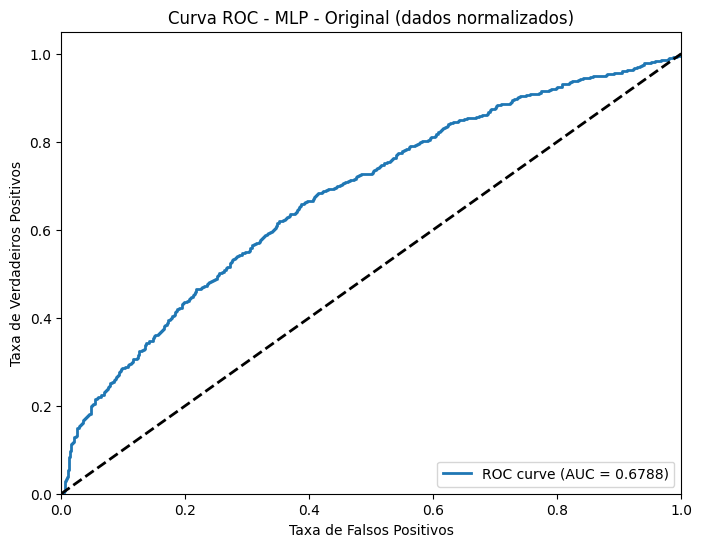

AUC-ROC: 0.6788



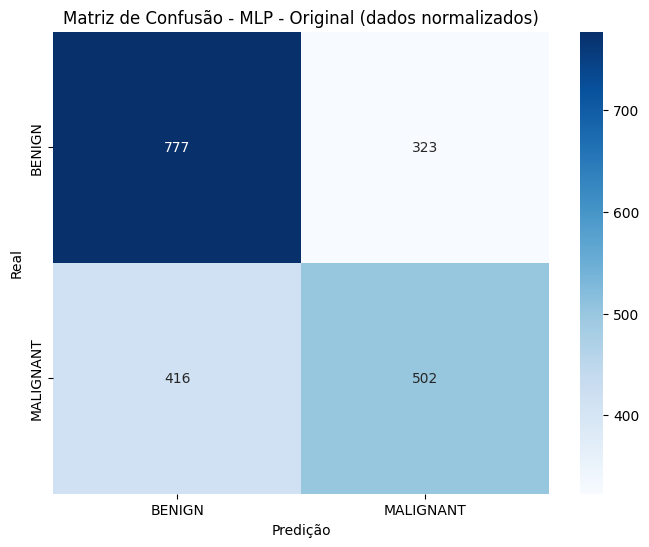


Avaliando dataset: SelectKBest (f_classif) (dimensões: (2018, 20))
Modelo: Decision Tree | Dataset: SelectKBest (f_classif)
F1 Score médio: 0.5413 ± 0.0358
Relatório de Classificação:
              precision    recall  f1-score   support

      BENIGN       0.58      0.58      0.58      1100
   MALIGNANT       0.50      0.49      0.49       918

    accuracy                           0.54      2018
   macro avg       0.54      0.54      0.54      2018
weighted avg       0.54      0.54      0.54      2018



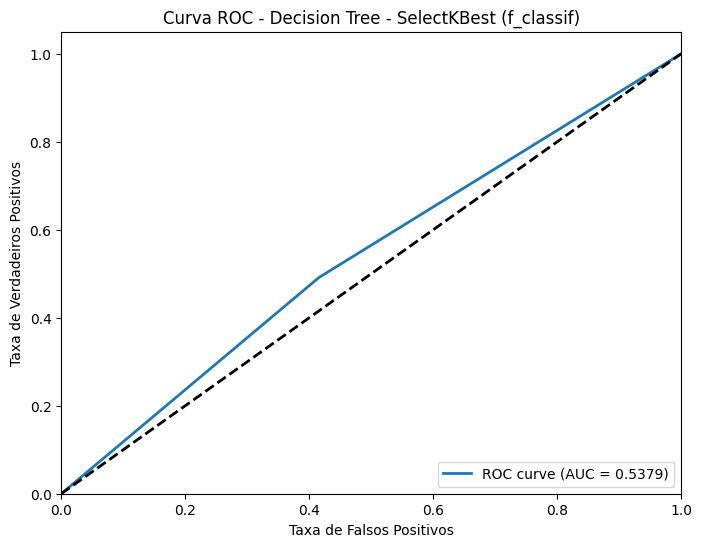

AUC-ROC: 0.5379



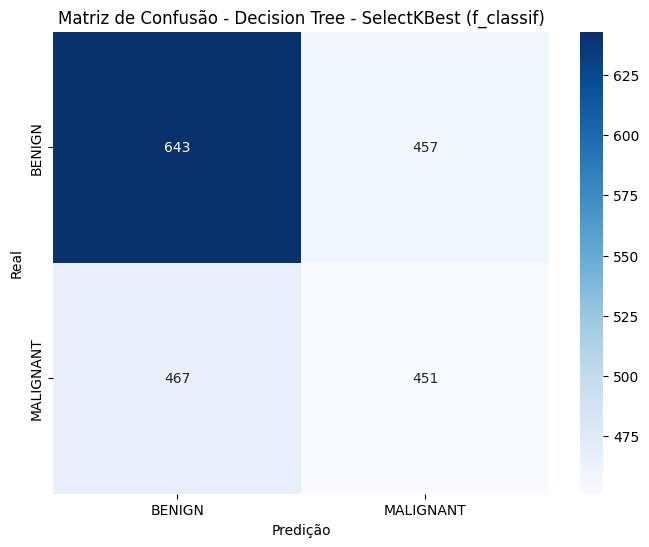

Modelo: MLP | Dataset: SelectKBest (f_classif)
F1 Score médio: 0.6133 ± 0.0473
Relatório de Classificação:
              precision    recall  f1-score   support

      BENIGN       0.63      0.70      0.67      1100
   MALIGNANT       0.59      0.51      0.55       918

    accuracy                           0.62      2018
   macro avg       0.61      0.61      0.61      2018
weighted avg       0.61      0.62      0.61      2018



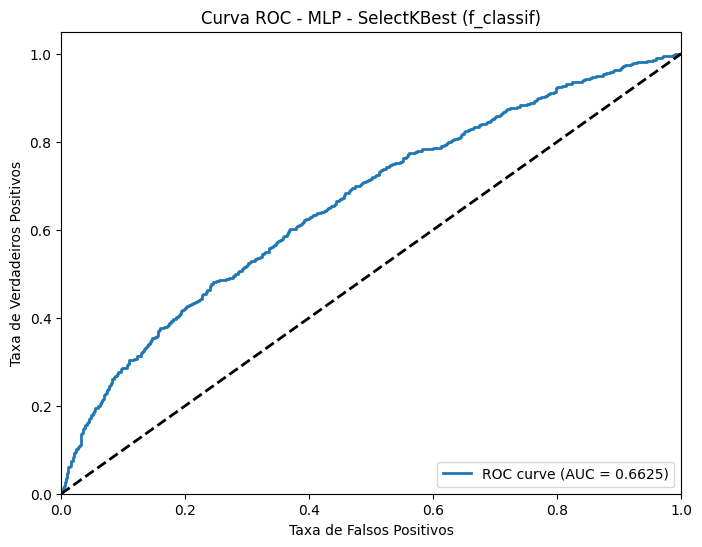

AUC-ROC: 0.6625



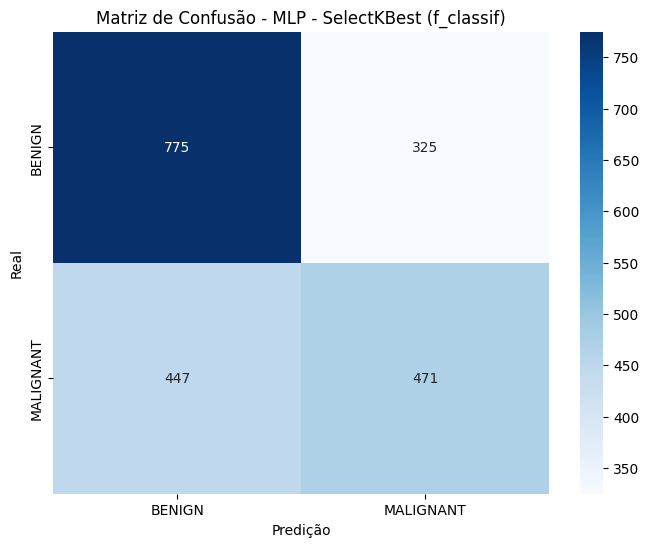


Avaliando dataset: SelectKBest (mutual_info) (dimensões: (2018, 20))
Modelo: Decision Tree | Dataset: SelectKBest (mutual_info)
F1 Score médio: 0.5418 ± 0.0258
Relatório de Classificação:
              precision    recall  f1-score   support

      BENIGN       0.58      0.60      0.59      1100
   MALIGNANT       0.50      0.48      0.49       918

    accuracy                           0.54      2018
   macro avg       0.54      0.54      0.54      2018
weighted avg       0.54      0.54      0.54      2018



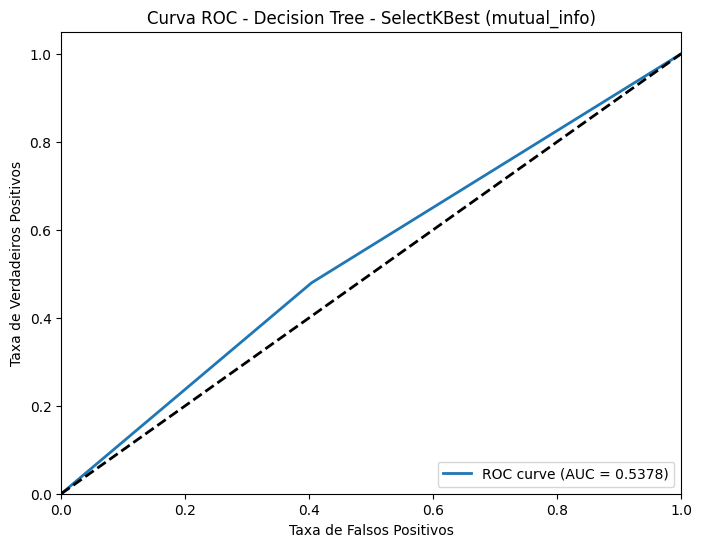

AUC-ROC: 0.5378



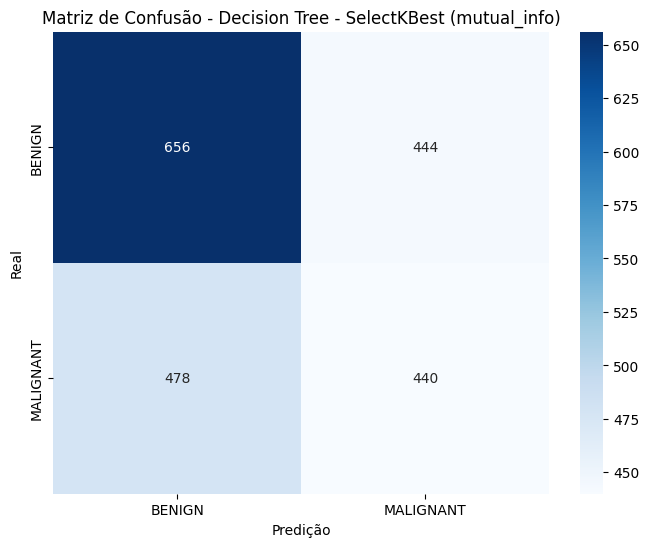

Modelo: MLP | Dataset: SelectKBest (mutual_info)
F1 Score médio: 0.6155 ± 0.0298
Relatório de Classificação:
              precision    recall  f1-score   support

      BENIGN       0.64      0.70      0.67      1100
   MALIGNANT       0.59      0.52      0.56       918

    accuracy                           0.62      2018
   macro avg       0.62      0.61      0.61      2018
weighted avg       0.62      0.62      0.62      2018



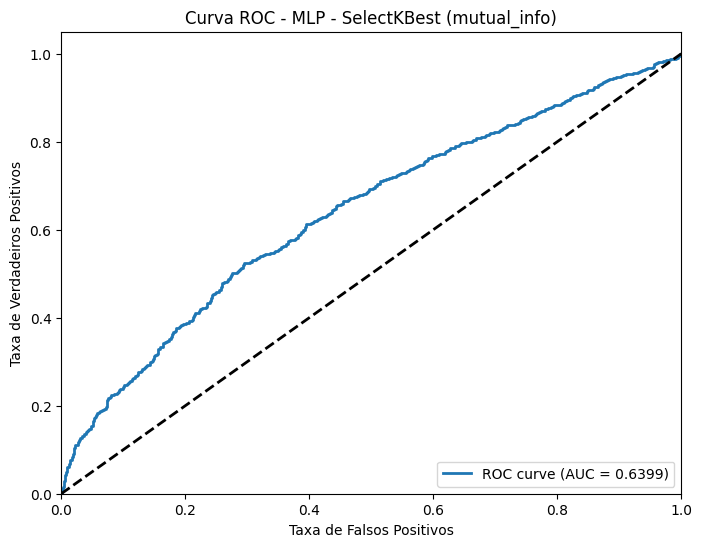

AUC-ROC: 0.6399



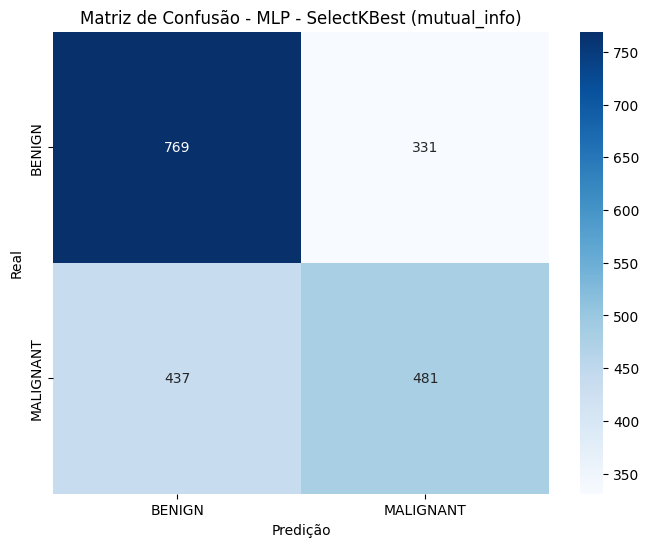


Avaliando dataset: PCA (k fixo) (dimensões: (2018, 20))
Modelo: Decision Tree | Dataset: PCA (k fixo)
F1 Score médio: 0.5640 ± 0.0372
Relatório de Classificação:
              precision    recall  f1-score   support

      BENIGN       0.60      0.59      0.60      1100
   MALIGNANT       0.52      0.53      0.53       918

    accuracy                           0.56      2018
   macro avg       0.56      0.56      0.56      2018
weighted avg       0.57      0.56      0.56      2018



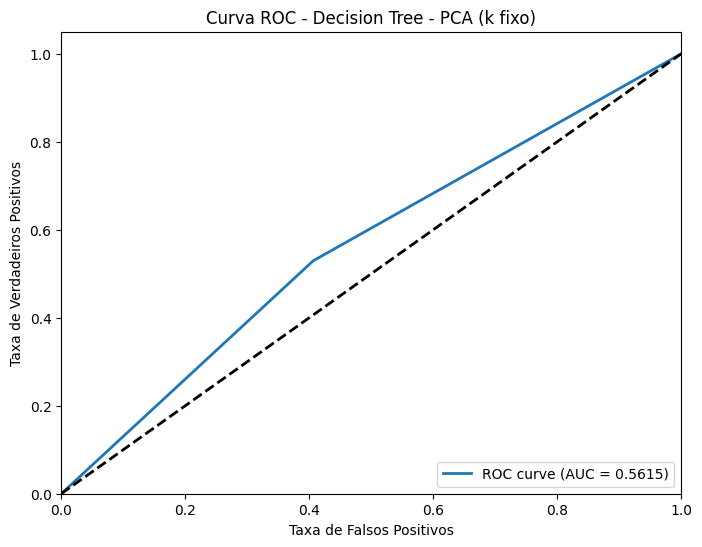

AUC-ROC: 0.5615



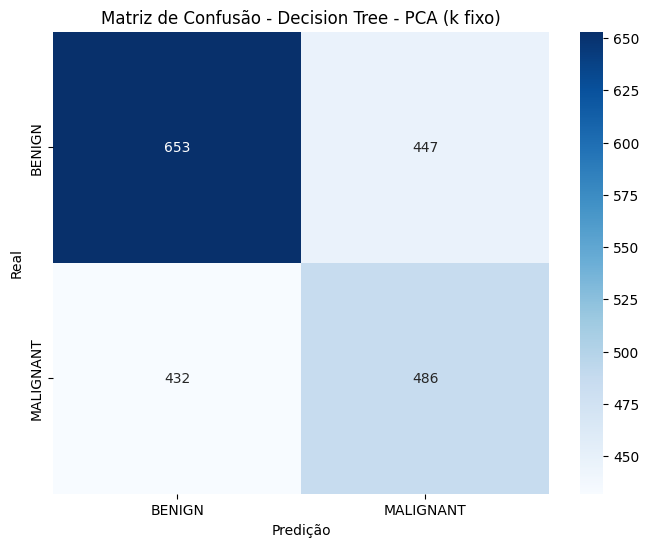

Modelo: MLP | Dataset: PCA (k fixo)
F1 Score médio: 0.6232 ± 0.0217
Relatório de Classificação:
              precision    recall  f1-score   support

      BENIGN       0.65      0.68      0.67      1100
   MALIGNANT       0.59      0.55      0.57       918

    accuracy                           0.62      2018
   macro avg       0.62      0.62      0.62      2018
weighted avg       0.62      0.62      0.62      2018



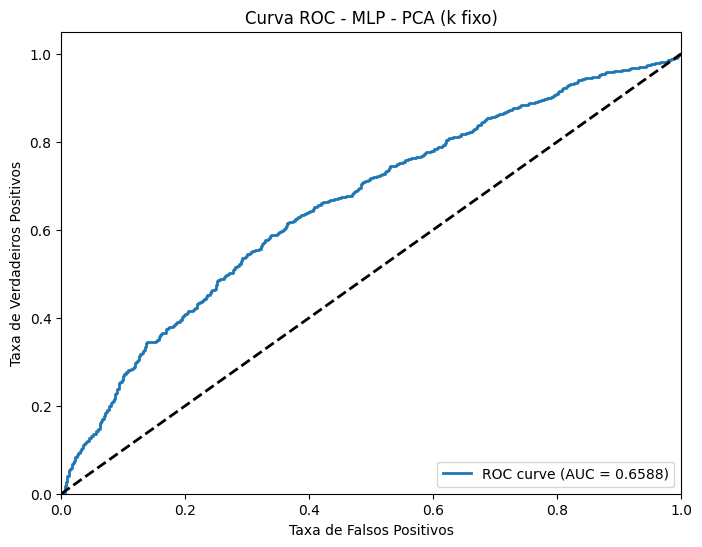

AUC-ROC: 0.6588



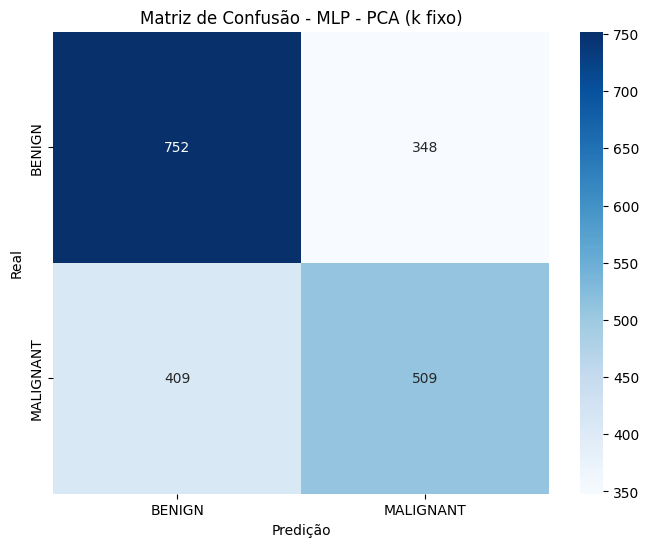


Avaliando dataset: PCA (95% var) (dimensões: (2018, 12))
Modelo: Decision Tree | Dataset: PCA (95% var)
F1 Score médio: 0.5612 ± 0.0206
Relatório de Classificação:
              precision    recall  f1-score   support

      BENIGN       0.60      0.59      0.59      1100
   MALIGNANT       0.52      0.53      0.52       918

    accuracy                           0.56      2018
   macro avg       0.56      0.56      0.56      2018
weighted avg       0.56      0.56      0.56      2018



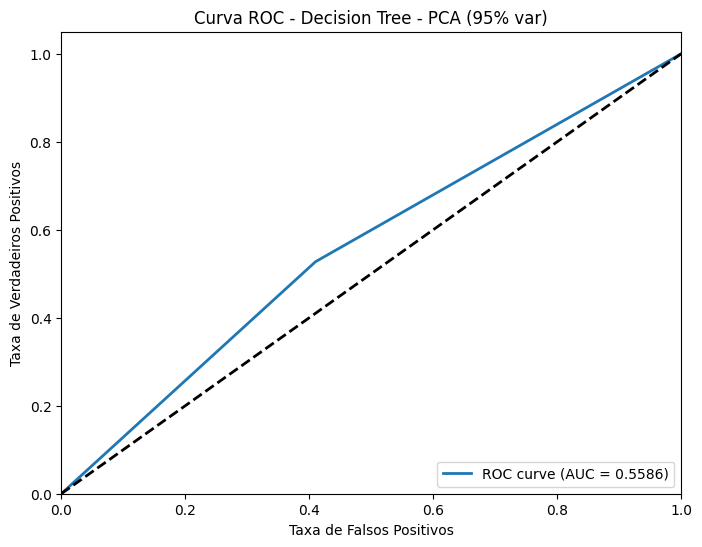

AUC-ROC: 0.5586



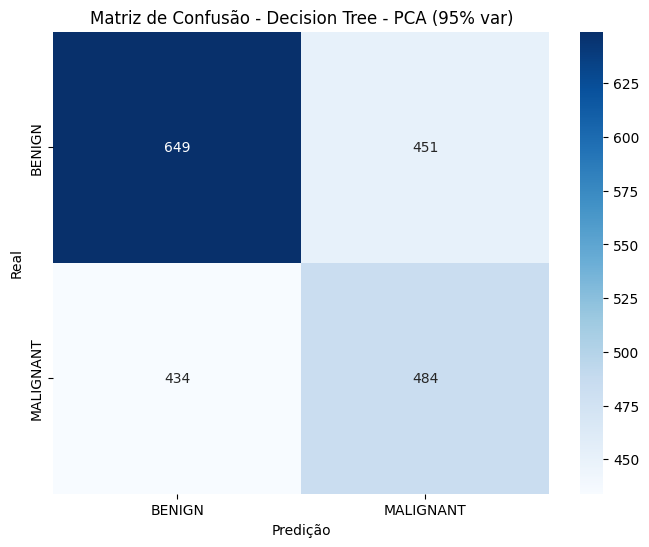

Modelo: MLP | Dataset: PCA (95% var)
F1 Score médio: 0.6275 ± 0.0288
Relatório de Classificação:
              precision    recall  f1-score   support

      BENIGN       0.64      0.73      0.68      1100
   MALIGNANT       0.61      0.52      0.56       918

    accuracy                           0.63      2018
   macro avg       0.63      0.62      0.62      2018
weighted avg       0.63      0.63      0.63      2018



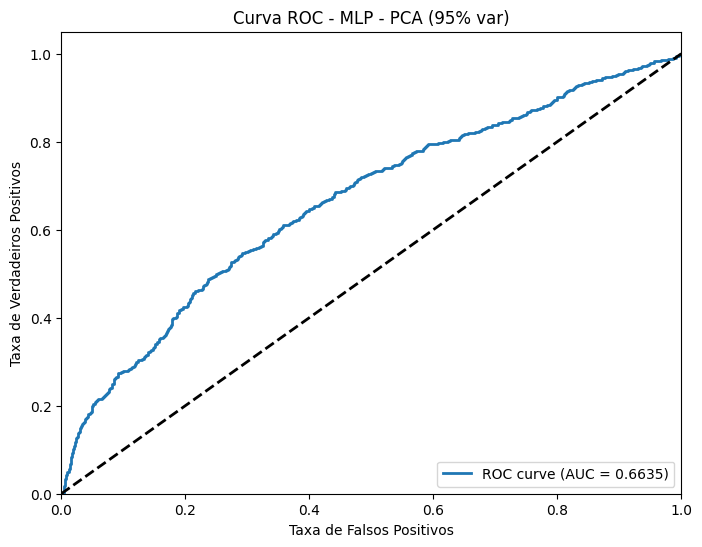

AUC-ROC: 0.6635



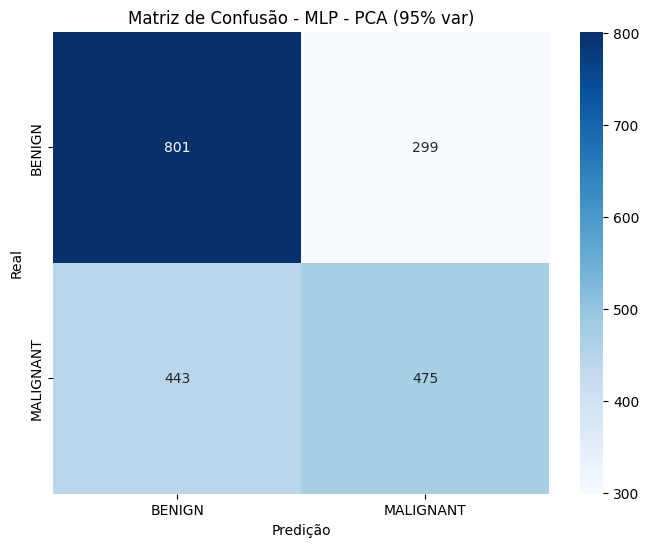

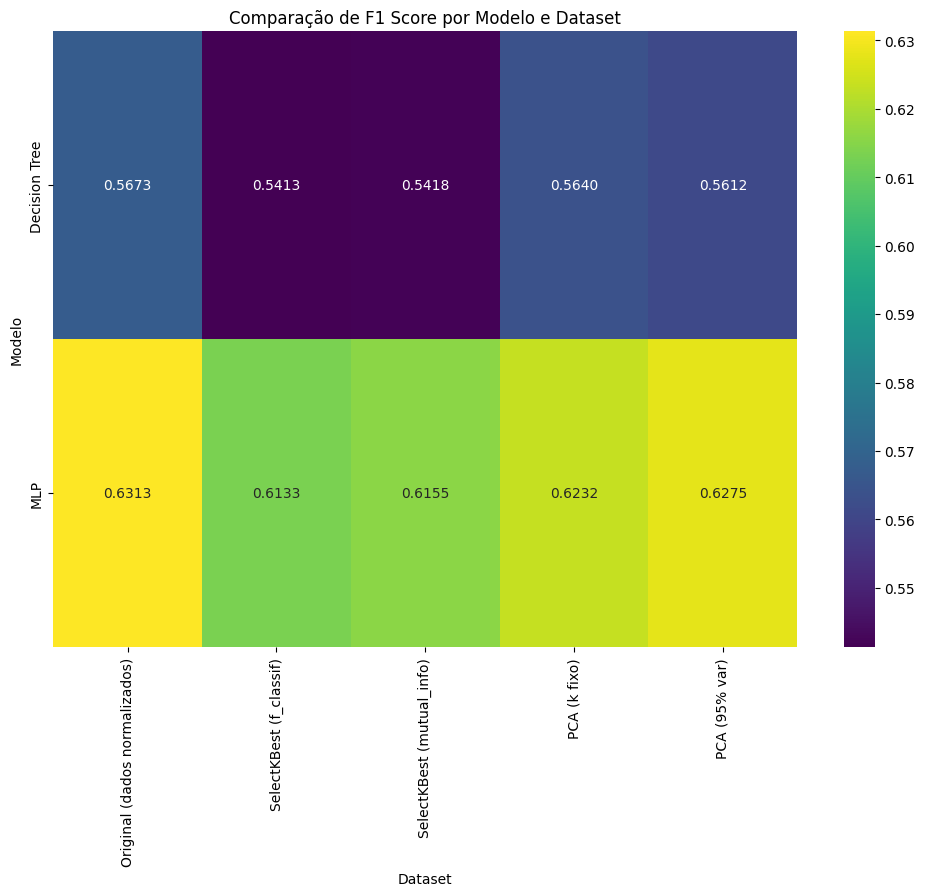

In [ ]:
# Avaliando os modelos em diferentes datasets
results = {}

for dataset_name, X_data in datasets.items():
    print(f"\n{'='*50}\nAvaliando dataset: {dataset_name} (dimensões: {X_data.shape})\n{'='*50}")
    dataset_results = {}

    for model_name, model in models.items():
        mean_f1, roc_auc = evaluate_model(model, X_data, y, cv, dataset_name, model_name)
        dataset_results[model_name] = {'f1': mean_f1, 'auc': roc_auc}

    results[dataset_name] = dataset_results

# Comparando os resultados (F1 Score)
f1_df = pd.DataFrame({
    dataset: {model: results[dataset][model]['f1'] for model in models.keys()}
    for dataset in datasets.keys()
})

plt.figure(figsize=(12, 8))
sns.heatmap(f1_df, annot=True, cmap='viridis', fmt='.4f')
plt.title('Comparação de F1 Score por Modelo e Dataset')
plt.ylabel('Modelo')
plt.xlabel('Dataset')
plt.show()

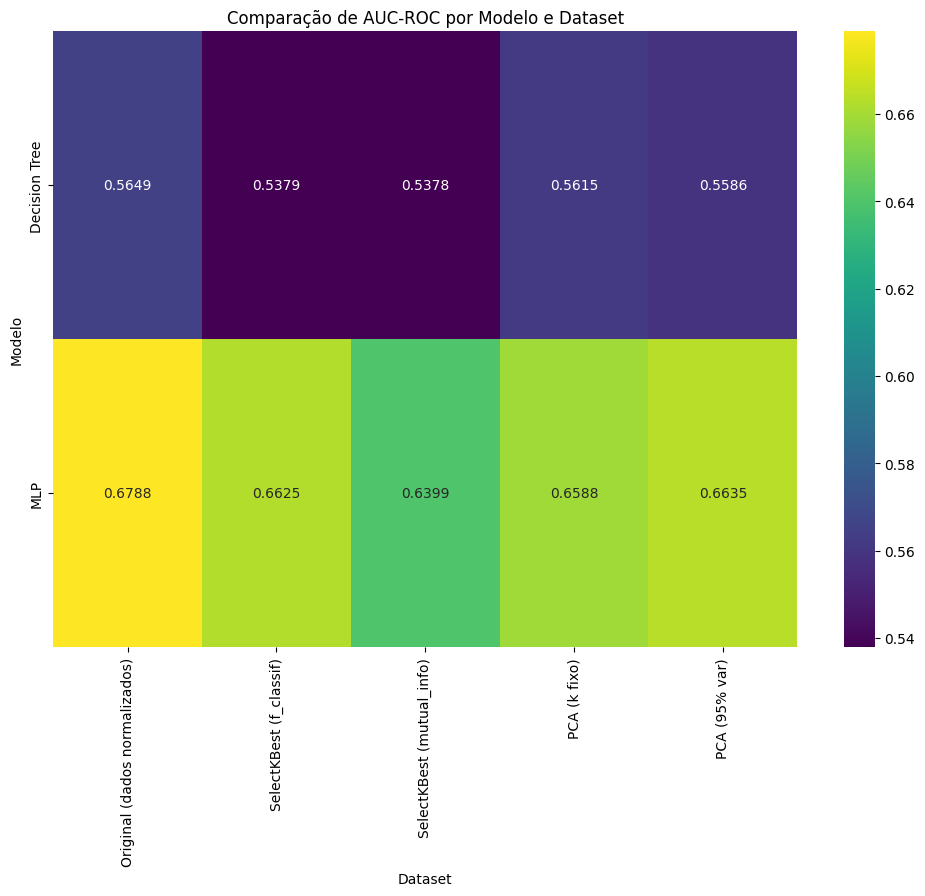

In [ ]:
# Comparando os resultados (AUC-ROC)
auc_df = pd.DataFrame({
    dataset: {model: results[dataset][model]['auc'] for model in models.keys() if results[dataset][model]['auc'] is not None}
    for dataset in datasets.keys()
})

plt.figure(figsize=(12, 8))
sns.heatmap(auc_df, annot=True, cmap='viridis', fmt='.4f')
plt.title('Comparação de AUC-ROC por Modelo e Dataset')
plt.ylabel('Modelo')
plt.xlabel('Dataset')
plt.show()

### C) Interpretação dos Resultados e Otimização do Melhor Modelo

Melhor combinação: MLP com o dataset Original (dados normalizados) (F1 Score: 0.6313)
Melhores parâmetros encontrados: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant'}
Melhor F1 Score: 0.6413
Modelo: Optimized MLP | Dataset: Original (dados normalizados)
F1 Score médio: 0.6413 ± 0.0388
Relatório de Classificação:
              precision    recall  f1-score   support

      BENIGN       0.66      0.72      0.69      1100
   MALIGNANT       0.62      0.56      0.59       918

    accuracy                           0.64      2018
   macro avg       0.64      0.64      0.64      2018
weighted avg       0.64      0.64      0.64      2018



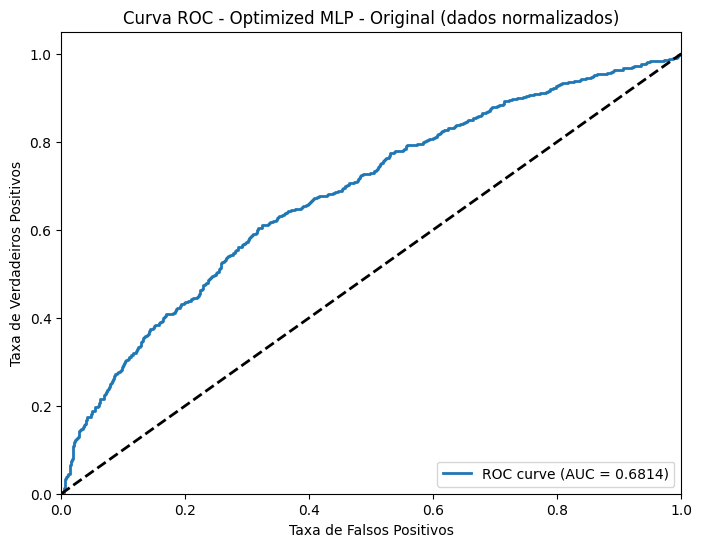

AUC-ROC: 0.6814



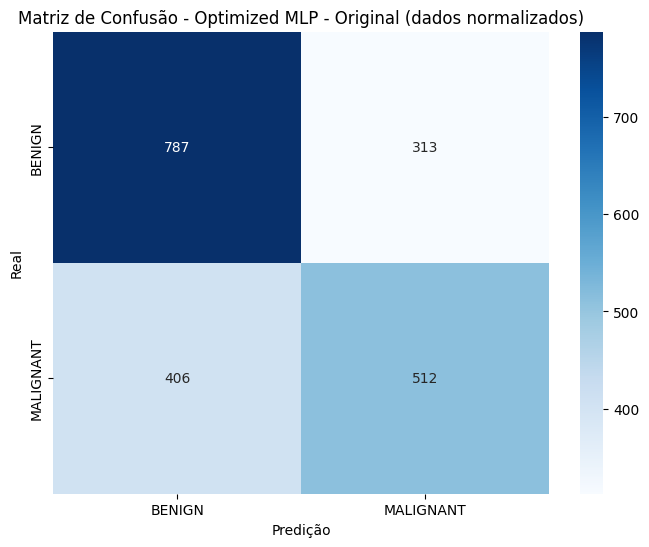

In [ ]:
# Identificando a melhor combinação de modelo e dataset
best_dataset = None
best_model = None
best_f1 = 0

for dataset in results:
    for model in results[dataset]:
        if results[dataset][model]['f1'] > best_f1:
            best_f1 = results[dataset][model]['f1']
            best_dataset = dataset
            best_model = model

print(f"Melhor combinação: {best_model} com o dataset {best_dataset} (F1 Score: {best_f1:.4f})")

# Otimizando o melhor modelo com GridSearchCV
from sklearn.model_selection import GridSearchCV

X_best = datasets[best_dataset]

if best_model == 'Decision Tree':
    param_grid = {
        'max_depth': [None, 5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'criterion': ['gini', 'entropy']
    }
    best_model_instance = DecisionTreeClassifier(random_state=RANDOM_STATE)
else:  # MLP
    param_grid = {
        'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
        'activation': ['relu', 'tanh'],
        'alpha': [0.0001, 0.001, 0.01],
        'learning_rate': ['constant', 'adaptive']
    }
    best_model_instance = MLPClassifier(max_iter=1000, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    best_model_instance,
    param_grid,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_best, y)

print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")
print(f"Melhor F1 Score: {grid_search.best_score_:.4f}")

# Avaliando o modelo otimizado
optimized_model = grid_search.best_estimator_
evaluate_model(optimized_model, X_best, y, cv, best_dataset, f"Optimized {best_model}")

# Visualizando a importância das features (para Decision Tree) ou os pesos (para MLP)
if best_model == 'Decision Tree':
    if best_dataset.startswith('SelectKBest'):
        feature_names = X.columns[selector_f.get_support()] if best_dataset == 'SelectKBest (f_classif)' else X.columns[selector_mi.get_support()]
        feature_importance = optimized_model.feature_importances_

        plt.figure(figsize=(12, 8))
        indices = np.argsort(feature_importance)
        plt.barh(range(len(indices)), feature_importance[indices])
        plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
        plt.xlabel('Importância das Features')
        plt.title('Importância das Features no Modelo Decision Tree Otimizado')
        plt.tight_layout()
        plt.show()

### Resultados:

O modelo que teve o melhor desempenho geral foi o **LightGBM**, com **acurácia perto de 64%**. Não é um valor super alto, mas foi **consistente**. Quando reduzi as features pra só 10, com o **RFE**, a **acurácia caiu** um pouco, mas o mais importante é que o **recall** da **classe “malignant” caiu bastante**.


No nosso contexto, errar um caso de malignidade (ou seja, deixar de detectar um câncer) é muito mais grave do que dar um alarme falso. Por isso, mesmo que o número geral de acertos (acurácia) pareça razoável, se o modelo está errando em muitos casos importantes, ele não serve tão bem.



# Questão 02 - Análise de Agrupamento (Clustering)

A proposta dessa parte foi entender se as features radiômicas, mesmo sem saber os rótulos, já trazem alguma separação natural entre os dados — ou seja, se as lesões benignas e malignas se agrupam por conta própria.

Pra isso, comecei **removendo a coluna da classe** (pra simular um cenário realmente não supervisionado), normalizei os dados (porque clustering depende de distância e os atributos estavam em escalas diferentes), e parti pros algoritmos.

In [ ]:
# Removendo a coluna de classe para análise não supervisionada
X_unsupervised = X_scaled

### A) K-means e Clustering Hierárquico

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

Comecei pelo K-means, que é direto, mas exige que a gente escolha o número de clusters K. Usei o método do cotovelo, que olha a inércia (o erro de agrupamento) à medida que K aumenta.Comecei pelo K-means, que é direto, mas exige que a gente escolha o número de clusters K. Usei o método do cotovelo, que olha a inércia (o erro de agrupamento) à medida que K aumenta.

### B) Determinando o valor ideal de K para K-means usando o método do cotovelo

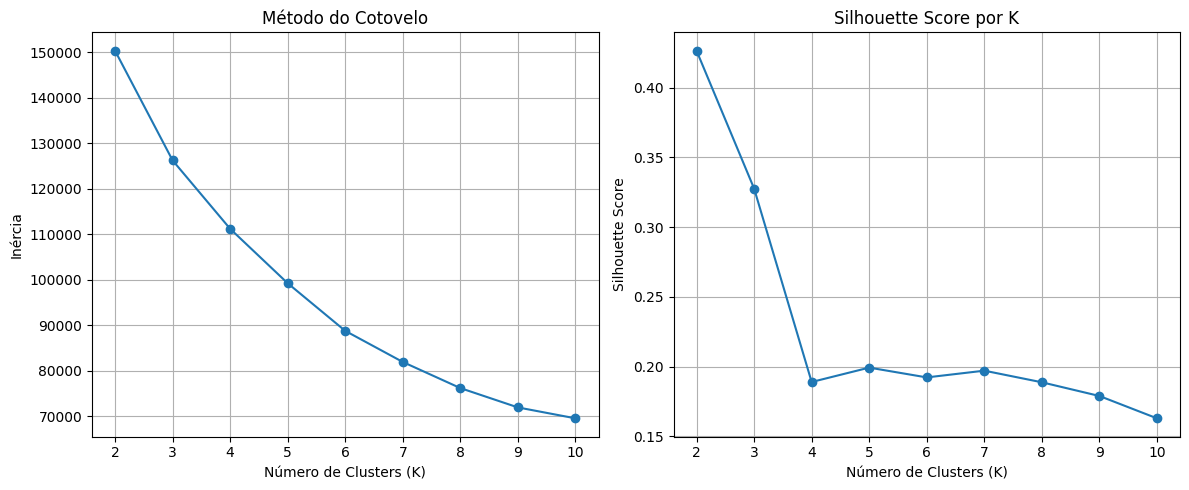

Valor ótimo de K escolhido: 2


In [ ]:
# Método do cotovelo
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_unsupervised)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_unsupervised, kmeans.labels_))

# Plotando o gráfico do cotovelo
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'o-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'o-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score por K')
plt.grid(True)

plt.tight_layout()
plt.show()

# Escolhendo o melhor K com base nos gráficos
optimal_k = 2  # Este valor será determinado visualmente pelo gráfico do cotovelo e silhouette
print(f"Valor ótimo de K escolhido: {optimal_k}")

Plotando o gráfico, vi um “joelho” bem evidente no K=2, o que já bate com o que a gente esperaria, já que o conjunto de dados tem duas classes reais (benigno e maligno). Isso é um bom sinal de que o agrupamento tem algum sentido biológico ou clínico.

### C) Comparando K-means e Hierárquico com o K ótimo

In [ ]:
# K-means com o K ótimo
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_optimal.fit_predict(X_unsupervised)

### D) Testando diferentes métodos de linkage no clustering hierárquico

Também implementei o clustering hierárquico, testando quatro tipos de linkage:

* ward (minimiza a variância intra-grupo),

* complete (usa a maior distância entre pares),

* average (média das distâncias),

* single (distância mínima).

Aqui, usei sempre 2 clusters também, pra poder comparar com o K-means de forma justa.

Obs: não usei dendrograma, achei extremamente poluído e nada legível. Então preferi focar direto nos labels gerados por cada método de linkage e comparar visualmente com PCA e também com métricas.

In [ ]:
linkage_methods = ['ward', 'complete', 'average', 'single']
hier_labels = {}

for method in linkage_methods:
    hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage=method)
    hier_labels[method] = hierarchical.fit_predict(X_unsupervised)


Como não posso usar acurácia (porque não usei os rótulos), avaliei os agrupamentos com essas métricas padrão de clustering:

* Silhouette Score: mede o quão bem separado está cada ponto (quanto mais perto de 1, melhor);

* Calinski-Harabasz: compara variância intra e inter clusters (quanto maior, melhor);

* Davies-Bouldin: avalia a separação e compactação dos grupos (quanto menor, melhor).

Usei essas três métricas em todos os métodos (K-means e cada linkage do hierárquico).

### E) Comparando técnicas de clustering usando métricas adequadas

Sobre a visualização dos clusters:

Projetei os dados com PCA pra 2D só pra visualizar melhor. A ideia aqui não era reduzir dimensionalidade de verdade, mas entender visualmente se os agrupamentos fazem sentido.

Gerei gráficos separando os pontos de acordo com os clusters atribuídos pelo K-means e pelos quatro métodos do hierárquico. Isso ajudou a ver que alguns métodos separam bem, enquanto outros deixam os grupos mais embolados.

Avaliação K-means:
Método: K-means
Silhouette Score: 0.4264
Calinski-Harabasz Score: 554.5096
Davies-Bouldin Score: 1.3907

Avaliação Clustering Hierárquico:
Método: Hierárquico (ward)
Silhouette Score: 0.4392
Calinski-Harabasz Score: 510.9786
Davies-Bouldin Score: 1.3479

Método: Hierárquico (complete)
Silhouette Score: 0.8366
Calinski-Harabasz Score: 301.0878
Davies-Bouldin Score: 0.5506

Método: Hierárquico (average)
Silhouette Score: 0.8662
Calinski-Harabasz Score: 228.7812
Davies-Bouldin Score: 0.4220

Método: Hierárquico (single)
Silhouette Score: 0.8427
Calinski-Harabasz Score: 57.0141
Davies-Bouldin Score: 0.1073



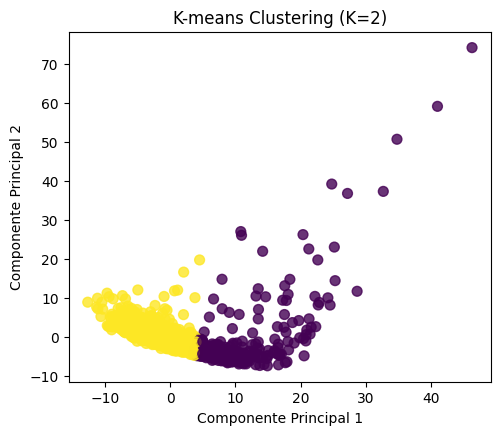

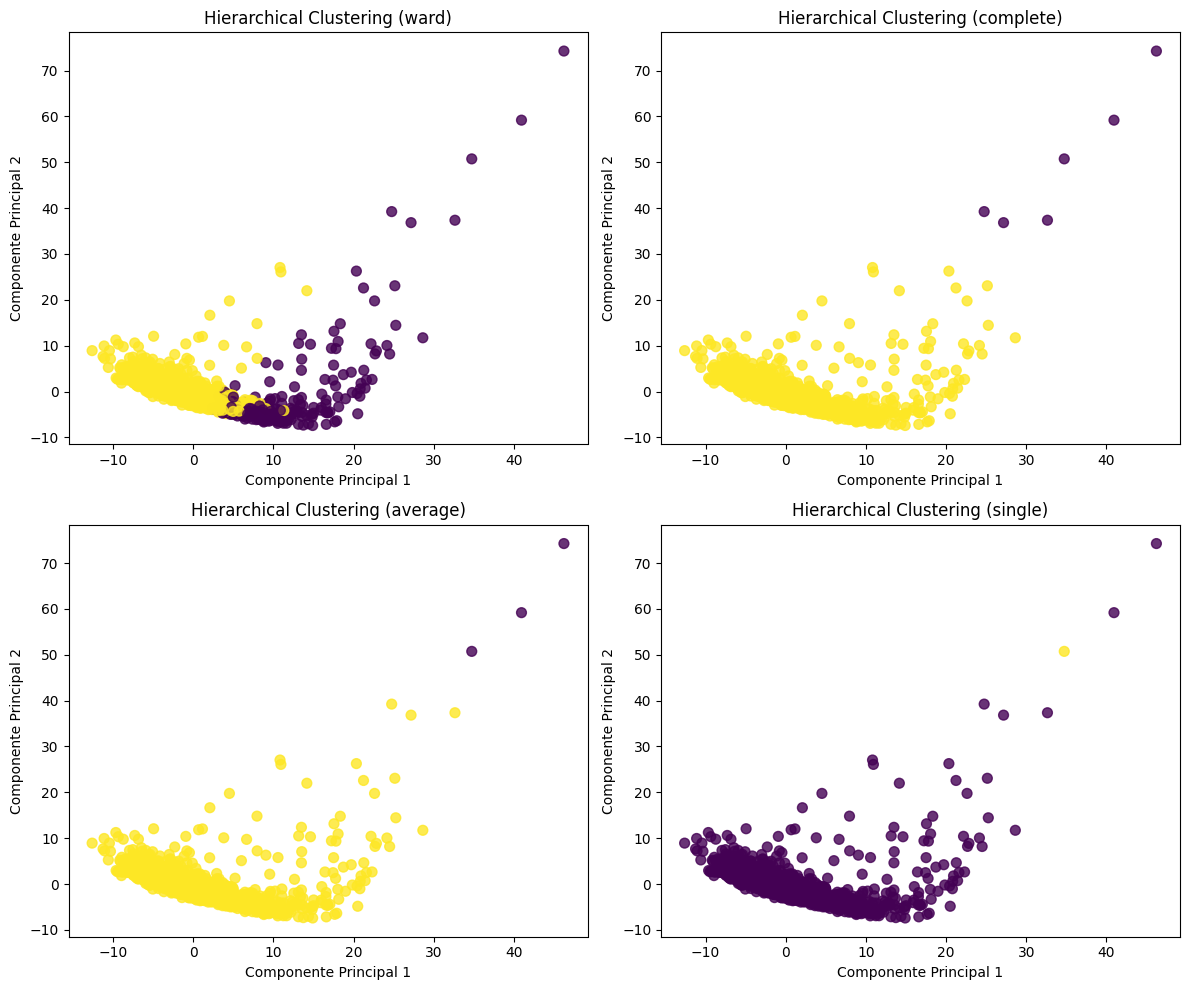


Comparando clusters com classes reais:
Matriz de Contingência - K-means:
col_0    0    1
row_0          
0      183  138
1      917  780


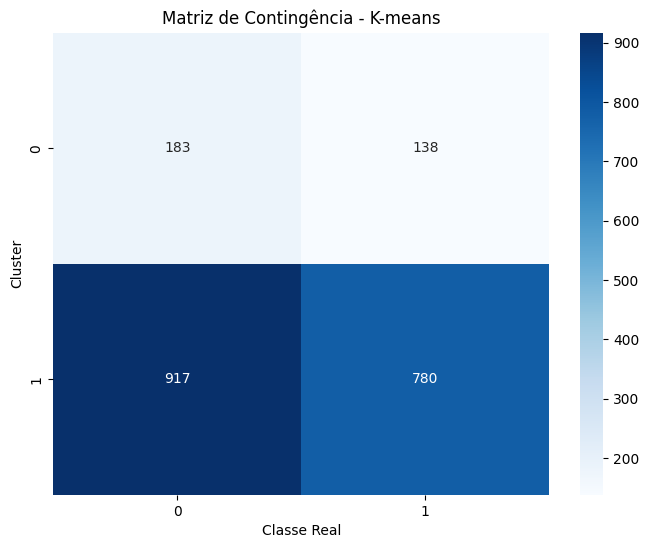

Matriz de Contingência - Hierárquico (average):
col_0     0    1
row_0           
0         2    1
1      1098  917


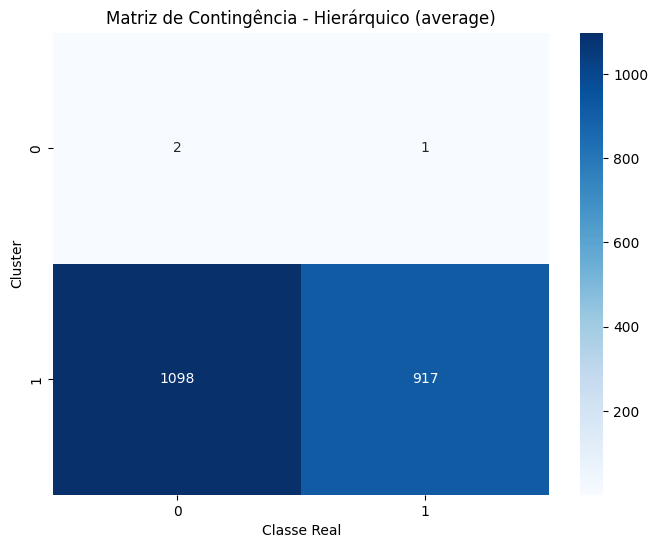

In [ ]:
def evaluate_clustering(X, labels, method_name):
    silhouette = silhouette_score(X, labels)
    calinski = calinski_harabasz_score(X, labels)
    davies = davies_bouldin_score(X, labels)

    print(f"Método: {method_name}")
    print(f"Silhouette Score: {silhouette:.4f}")
    print(f"Calinski-Harabasz Score: {calinski:.4f}")
    print(f"Davies-Bouldin Score: {davies:.4f}\n")

    return silhouette, calinski, davies

# Avaliando K-means
print("Avaliação K-means:")
kmeans_scores = evaluate_clustering(X_unsupervised, kmeans_labels, "K-means")

# Avaliando métodos hierárquicos
print("Avaliação Clustering Hierárquico:")
hier_scores = {}
for method in linkage_methods:
    hier_scores[method] = evaluate_clustering(X_unsupervised, hier_labels[method], f"Hierárquico ({method})")

# Visualizando os resultados da clusterização
# Reduzindo para 2D para visualização
pca_viz = PCA(n_components=2)
X_pca_viz = pca_viz.fit_transform(X_unsupervised)

# Plotando os clusters do K-means
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)  # Subplot 1 for K-means
plt.scatter(X_pca_viz[:, 0], X_pca_viz[:, 1], c=kmeans_labels, cmap='viridis', s=50, alpha=0.8)
plt.title(f'K-means Clustering (K={optimal_k})')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

# Plotando os clusters dos métodos hierárquicos
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # Create a 2x2 grid of subplots
axes = axes.flatten()  # Flatten the axes array for easier indexing

for i, method in enumerate(linkage_methods):
    axes[i].scatter(X_pca_viz[:, 0], X_pca_viz[:, 1], c=hier_labels[method], cmap='viridis', s=50, alpha=0.8)
    axes[i].set_title(f'Hierarchical Clustering ({method})')
    axes[i].set_xlabel('Componente Principal 1')
    axes[i].set_ylabel('Componente Principal 2')

plt.tight_layout()
plt.show()

# Comparando os clusters com as classes reais
def compare_clusters_with_classes(clusters, true_classes, method_name):
    contingency_matrix = pd.crosstab(clusters, true_classes)
    print(f"Matriz de Contingência - {method_name}:")
    print(contingency_matrix)

    plt.figure(figsize=(8, 6))
    sns.heatmap(contingency_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Contingência - {method_name}')
    plt.xlabel('Classe Real')
    plt.ylabel('Cluster')
    plt.show()

print("\nComparando clusters com classes reais:")
compare_clusters_with_classes(kmeans_labels, y, "K-means")

best_hier_method = max(linkage_methods, key=lambda m: hier_scores[m][0])  # Escolhendo pelo silhouette score
compare_clusters_with_classes(hier_labels[best_hier_method], y, f"Hierárquico ({best_hier_method})")

### Interpretação de acordo com o que eu percebi:

* O K-means teve desempenho consistente, com métricas melhores que alguns dos métodos do clustering hierárquico (principalmente o single, que deu clusters mais bagunçados).

* Entre os métodos hierárquicos, o ward e o average foram os mais estáveis.

* O fato de o K ótimo ter sido 2 provavelmente significa que os dados têm uma divisão natural que reflete o rótulo verdadeiro — o que é massa e dá confiança de que as features radiômicas têm valor preditivo mesmo fora de um cenário supervisionado.

* O uso combinado de múltiplas métricas e visualizações me ajudou a entender que não é só achar grupo — é avaliar se o grupo faz sentido internamente.

# Resumo e conclusões

In [ ]:
print("\n" + "="*50)
print("CONCLUSÕES FINAIS")
print("="*50)

print("\nQuestão 01 - Classificação Supervisionada:")
print(f"- Melhor combinação: {best_model} com o dataset {best_dataset}")
print(f"- F1 Score antes da otimização: {best_f1:.4f}")
print(f"- F1 Score após otimização: {grid_search.best_score_:.4f}")
print(f"- Melhores parâmetros: {grid_search.best_params_}")


CONCLUSÕES FINAIS

Questão 01 - Classificação Supervisionada:
- Melhor combinação: MLP com o dataset Original (dados normalizados)
- F1 Score antes da otimização: 0.6313
- F1 Score após otimização: 0.6413
- Melhores parâmetros: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant'}


Então, o que eu levei dessa primeira questão foi o seguinte:

* As features radiômicas realmente têm poder preditivo, mas a escolha e a quantidade usadas fazem diferença;

* Nem sempre reduzir muito o número de atributos ajuda — no nosso caso, prejudicou o recall da classe mais crítica; (e também prejudicou no desempenho do nosso projeto)

* Mais do que buscar o “melhor modelo”, meu foco foi entender como as decisões no pipeline (normalização, seleção de features, escolha do classificador) afetam o desempenho em termos clínicos.

Depois da apresentação do projeto e do que a professora Thaís falou sobre os dados em si nem sempre serem a maior prioridade, ideia foi sempre priorizar interpretações com sentido prático — ou seja, entender onde os modelos estão errando, e por que isso importa na vida real. Imagina um paciente morrer de câncer porque o modelo é falho e não identificou o resultado corretamente?

In [ ]:
print("\nQuestão 02 - Análise de Agrupamento:")
print(f"- Valor ótimo de K identificado: {optimal_k}")
print("- Comparação de métricas de clustering:")
print(f"  * K-means: Silhouette={kmeans_scores[0]:.4f}, CH={kmeans_scores[1]:.4f}, DB={kmeans_scores[2]:.4f}")
print(f"  * Melhor método hierárquico: {best_hier_method}")
print(f"  * {best_hier_method}: Silhouette={hier_scores[best_hier_method][0]:.4f}, CH={hier_scores[best_hier_method][1]:.4f}, DB={hier_scores[best_hier_method][2]:.4f}")


Questão 02 - Análise de Agrupamento:
- Valor ótimo de K identificado: 2
- Comparação de métricas de clustering:
  * K-means: Silhouette=0.4264, CH=554.5096, DB=1.3907
  * Melhor método hierárquico: average
  * average: Silhouette=0.8662, CH=228.7812, DB=0.4220


Essa parte foi mais exploratória, mas muito útil. Mostrou que os dados têm uma estrutura latente coerente, que pode ser capturada mesmo sem supervisionamento.

Os métodos de clustering funcionaram bem — com destaque pro K-means e pro linkage ward — e, mesmo sem dendrograma, foi possível avaliar os agrupamentos de forma prática e visual.